<a href="https://colab.research.google.com/github/Supriya6462/Big-Data/blob/main/Final%20Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install PySpark and ML libraries
!pip install pyspark findspark --quiet
!pip install imbalanced-learn xgboost lightgbm optuna scikit-learn seaborn matplotlib --quiet
print(' All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.6 MB/s eta 0:00:00
 All packages installed.


## STEP 2 · Start Spark Session

In [4]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName('Assessment3_Preprocessing')
    .config('spark.driver.memory', '4g')
    .config('spark.sql.shuffle.partitions', '8')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')
print(f'Spark version: {spark.version}')
print(f'   App name    : {spark.sparkContext.appName}')

Spark version: 4.0.2
   App name    : Assessment3_Preprocessing


##STEP 3 · Load CSV into Spark DataFrame

In [5]:
# CONFIGURE THESE TWO LINES
FILE_PATH     = '/content/drive/MyDrive/Big-Data/HC_application_train.csv'
TARGET_COLUMN = 'TARGET'

sdf = (
    spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .option('nullValue', 'NA')
    .csv(FILE_PATH)
)

print(f' Loaded — rows: {sdf.count():,}   cols: {len(sdf.columns)}')
print(f'   Target column: {TARGET_COLUMN}')
sdf.printSchema()
sdf.show(5, truncate=True)

 Loaded — rows: 307,511   cols: 122
   Target column: TARGET
root
 |-- SK_ID_CURR: integer (nullable = true)
 |-- TARGET: integer (nullable = true)
 |-- NAME_CONTRACT_TYPE: string (nullable = true)
 |-- CODE_GENDER: string (nullable = true)
 |-- FLAG_OWN_CAR: string (nullable = true)
 |-- FLAG_OWN_REALTY: string (nullable = true)
 |-- CNT_CHILDREN: integer (nullable = true)
 |-- AMT_INCOME_TOTAL: double (nullable = true)
 |-- AMT_CREDIT: double (nullable = true)
 |-- AMT_ANNUITY: double (nullable = true)
 |-- AMT_GOODS_PRICE: double (nullable = true)
 |-- NAME_TYPE_SUITE: string (nullable = true)
 |-- NAME_INCOME_TYPE: string (nullable = true)
 |-- NAME_EDUCATION_TYPE: string (nullable = true)
 |-- NAME_FAMILY_STATUS: string (nullable = true)
 |-- NAME_HOUSING_TYPE: string (nullable = true)
 |-- REGION_POPULATION_RELATIVE: double (nullable = true)
 |-- DAYS_BIRTH: integer (nullable = true)
 |-- DAYS_EMPLOYED: integer (nullable = true)
 |-- DAYS_REGISTRATION: double (nullable = true)
 |

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## STEP 4 · Spark — Inspect Data Quality

In [7]:
from pyspark.sql import functions as F

total_rows = sdf.count()

#Null counts per column
null_counts = sdf.select(
    [F.sum(F.col(c).isNull().cast('int')).alias(c) for c in sdf.columns]
).collect()[0].asDict()

print('── Null counts (top 20 columns with most nulls)')
sorted_nulls = sorted(null_counts.items(), key=lambda x: x[1], reverse=True)[:20]
for col, cnt in sorted_nulls:
    pct = cnt / total_rows * 100
    bar = '' * int(pct / 2)
    print(f'  {col:<40} {cnt:>8,}  ({pct:5.1f}%) {bar}')

# Target distribution
print(f'\n Target distribution ({TARGET_COLUMN}) ')
sdf.groupBy(TARGET_COLUMN).count().orderBy(TARGET_COLUMN).show()

── Null counts (top 20 columns with most nulls)
  COMMONAREA_AVG                            214,865  ( 69.9%) 
  COMMONAREA_MODE                           214,865  ( 69.9%) 
  COMMONAREA_MEDI                           214,865  ( 69.9%) 
  NONLIVINGAPARTMENTS_AVG                   213,514  ( 69.4%) 
  NONLIVINGAPARTMENTS_MODE                  213,514  ( 69.4%) 
  NONLIVINGAPARTMENTS_MEDI                  213,514  ( 69.4%) 
  FONDKAPREMONT_MODE                        210,295  ( 68.4%) 
  LIVINGAPARTMENTS_AVG                      210,199  ( 68.4%) 
  LIVINGAPARTMENTS_MODE                     210,199  ( 68.4%) 
  LIVINGAPARTMENTS_MEDI                     210,199  ( 68.4%) 
  FLOORSMIN_AVG                             208,642  ( 67.8%) 
  FLOORSMIN_MODE                            208,642  ( 67.8%) 
  FLOORSMIN_MEDI                            208,642  ( 67.8%) 
  YEARS_BUILD_AVG                           204,488  ( 66.5%) 
  YEARS_BUILD_MODE                          204,488  ( 66.5%) 
  YEARS

## STEP 5 · Spark — Drop High-Null Columns (>50% missing)

In [8]:
from pyspark.sql import functions as F

THRESHOLD = 0.5   # drop column if more than 50% rows are null

total_rows = sdf.count()

# Compute null fraction for every column in one pass
null_fractions = sdf.select(
    [(F.sum(F.col(c).isNull().cast('int')) / total_rows).alias(c)
     for c in sdf.columns]
).collect()[0].asDict()

cols_to_drop   = [c for c, frac in null_fractions.items() if frac > THRESHOLD]
cols_to_keep   = [c for c in sdf.columns if c not in cols_to_drop]

print(f'Columns before : {len(sdf.columns)}')
print(f'Columns dropped: {len(cols_to_drop)}  → {cols_to_drop}')
print(f'Columns kept   : {len(cols_to_keep)}')

sdf = sdf.select(cols_to_keep)
print(' High-null columns removed.')

Columns before : 122
Columns dropped: 41  → ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']
Columns kept   : 81
 High-null columns removed.


## ─── STEP 6 · Spark — Drop Rows with Too Many Nulls (>50% cols null) ─

In [9]:
from pyspark.sql import functions as F

n_cols = len(sdf.columns)
min_non_null = int(n_cols * 0.5)   # a row must have at least 50% non-null values

# Count nulls per row using a temporary column
null_per_row = F.expr(' + '.join([f'cast(`{c}` is null as int)' for c in sdf.columns]))

before = sdf.count()
sdf = sdf.filter(null_per_row <= (n_cols - min_non_null))
after = sdf.count()

print(f'Rows before : {before:,}')
print(f'Rows dropped: {before - after:,}')
print(f'Rows after  : {after:,}')
print(' Sparse rows removed.')

Rows before : 307,511
Rows dropped: 0
Rows after  : 307,511
 Sparse rows removed.


## STEP 7 · Spark — Fill Numeric Nulls with Column Median

In [13]:
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType

# Identify numeric columns (exclude target)
numeric_cols = [
    f.name for f in sdf.schema.fields
    if isinstance(f.dataType, NumericType) and f.name != TARGET_COLUMN
]

# Compute approximate medians in ONE Spark pass (exact median is very expensive)
approx_medians = sdf.approxQuantile(numeric_cols, [0.5], 0.001)
median_map = {col: vals[0] for col, vals in zip(numeric_cols, approx_medians) if vals}

# Fill nulls
sdf = sdf.fillna(median_map)

print(f' Numeric nulls filled with median — {len(numeric_cols)} columns processed.')
print('   Sample medians:', dict(list(median_map.items())[:5]))

 Numeric nulls filled with median — 67 columns processed.
   Sample medians: {'SK_ID_CURR': 277982.0, 'CNT_CHILDREN': 0.0, 'AMT_INCOME_TOTAL': 148500.0, 'AMT_CREDIT': 513531.0, 'AMT_ANNUITY': 24903.0}


## STEP 8 · Spark — Fill Categorical Nulls with Mode

In [16]:
from pyspark.sql.types import StringType

# Get categorical columns
cat_cols_spark = [
    field.name
    for field in sdf.schema.fields
    if isinstance(field.dataType, StringType)
]
mode_map = {}

for col in cat_cols_spark:
    mode_row = (
        sdf.filter(F.col(col).isNotNull())
           .groupBy(col)
           .count()
           .orderBy(F.col('count').desc())
           .first()
    )

    if mode_row is not None:
        mode_map[col] = mode_row[col]

# remove any accidental None values
mode_map = {k: v for k, v in mode_map.items() if v is not None}

sdf = sdf.fillna(mode_map)
print(f' Categorical nulls filled with mode — {len(mode_map)} columns processed.')
print('   Sample modes:', dict(list(mode_map.items())[:5]))

 Categorical nulls filled with mode — 13 columns processed.
   Sample modes: {'NAME_CONTRACT_TYPE': 'Cash loans', 'CODE_GENDER': 'F', 'FLAG_OWN_CAR': 'N', 'FLAG_OWN_REALTY': 'Y', 'NAME_TYPE_SUITE': 'Unaccompanied'}


##  STEP 9 · Spark — String Indexing (Label Encode Categoricals)

In [18]:
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.feature import StringIndexer

# Create one StringIndexer per categorical column
indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=col + '_idx',
        handleInvalid='keep'
    )
    for col in cat_cols_spark
]

# Fit & transform in a single Spark pipeline pass
if indexers:
    pipeline_si = SparkPipeline(stages=indexers)
    sdf = pipeline_si.fit(sdf).transform(sdf)
    sdf = sdf.drop(*cat_cols_spark)
    print(f'StringIndexer applied to {len(cat_cols_spark)} columns.')
else:
    print('No categorical columns to encode.')

print(f'DataFrame shape after encoding: rows={sdf.count():,}  cols={len(sdf.columns)}')

StringIndexer applied to 13 columns.
DataFrame shape after encoding: rows=307,511  cols=81


## ─── STEP 10 · Spark — Remove Constant / Duplicate Columns

In [19]:
from pyspark.sql import functions as F

feature_cols = [c for c in sdf.columns if c != TARGET_COLUMN]

# Compute distinct count per column in one pass
distinct_counts = sdf.select(
    [F.approx_count_distinct(c).alias(c) for c in feature_cols]
).collect()[0].asDict()

# Drop columns with only 1 unique value (constants)
constant_cols = [c for c, cnt in distinct_counts.items() if cnt <= 1]
if constant_cols:
    sdf = sdf.drop(*constant_cols)
    print(f'Dropped {len(constant_cols)} constant columns: {constant_cols}')
else:
    print('No constant columns found.')

print(f' Final Spark DataFrame: rows={sdf.count():,}  cols={len(sdf.columns)}')

No constant columns found.
 Final Spark DataFrame: rows=307,511  cols=81


## ─── STEP 11 · Spark → Pandas Conversion

In [20]:
print('Converting Spark DataFrame → Pandas ...')

df = sdf.toPandas()

# Stop Spark — no longer needed
spark.stop()
print(' Spark session stopped.')

print(f'\n Pandas DataFrame ready!')
print(f'   Shape  : {df.shape}')
print(f'   Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'   Nulls  : {df.isnull().sum().sum()}')
df.head()

Converting Spark DataFrame → Pandas ...
 Spark session stopped.

 Pandas DataFrame ready!
   Shape  : (307511, 81)
   Memory : 148.8 MB
   Nulls  : 0


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_OWN_REALTY_idx,NAME_TYPE_SUITE_idx,NAME_INCOME_TYPE_idx,NAME_EDUCATION_TYPE_idx,NAME_FAMILY_STATUS_idx,NAME_HOUSING_TYPE_idx,OCCUPATION_TYPE_idx,WEEKDAY_APPR_PROCESS_START_idx,ORGANIZATION_TYPE_idx,EMERGENCYSTATE_MODE_idx
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,...,1.0,1.0,3.0,1.0,0.0,0.0,2.0,2.0,7.0,0.0
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,6.0,0.0
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,...,0.0,0.0,0.0,0.0,1.0,0.0,2.0,3.0,53.0,0.0


## ─── STEP 12 · Install & Import ML Libraries (Pandas Phase)

In [21]:
import numpy as np
import pandas as pd
import warnings
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.model_selection  import (train_test_split, StratifiedKFold,
                                       cross_val_score, RandomizedSearchCV)
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from imblearn.over_sampling   import SMOTE
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from xgboost                  import XGBClassifier
from lightgbm                 import LGBMClassifier
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                       f1_score, roc_auc_score, classification_report,
                                       confusion_matrix, ConfusionMatrixDisplay,
                                       roc_curve, precision_recall_curve)

SEED = 42
np.random.seed(SEED)
print(' All ML libraries loaded.')

 All ML libraries loaded.


## STEP 14 · EDA — Pandas Visualisations

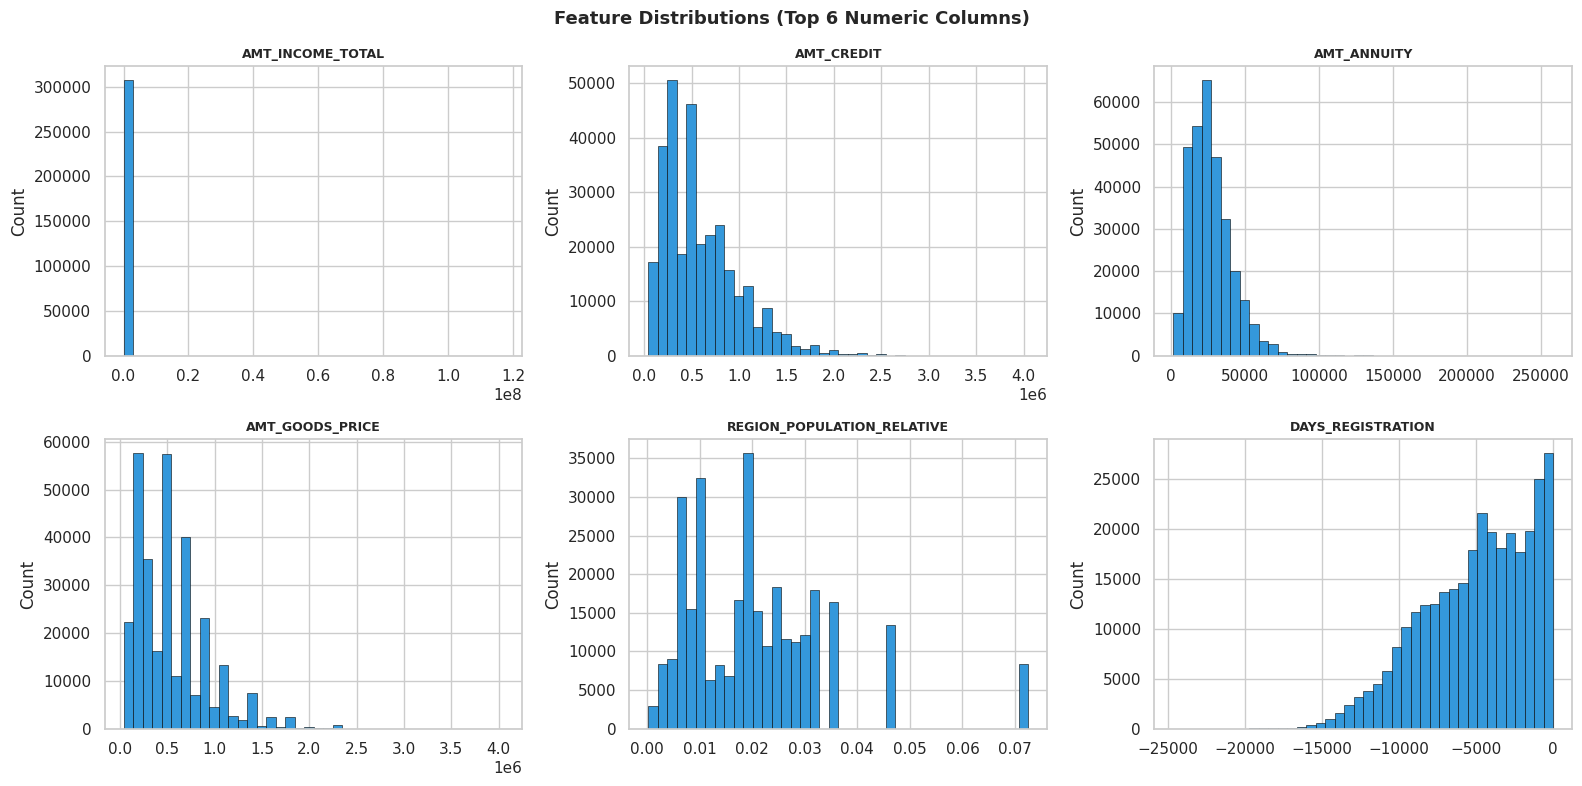

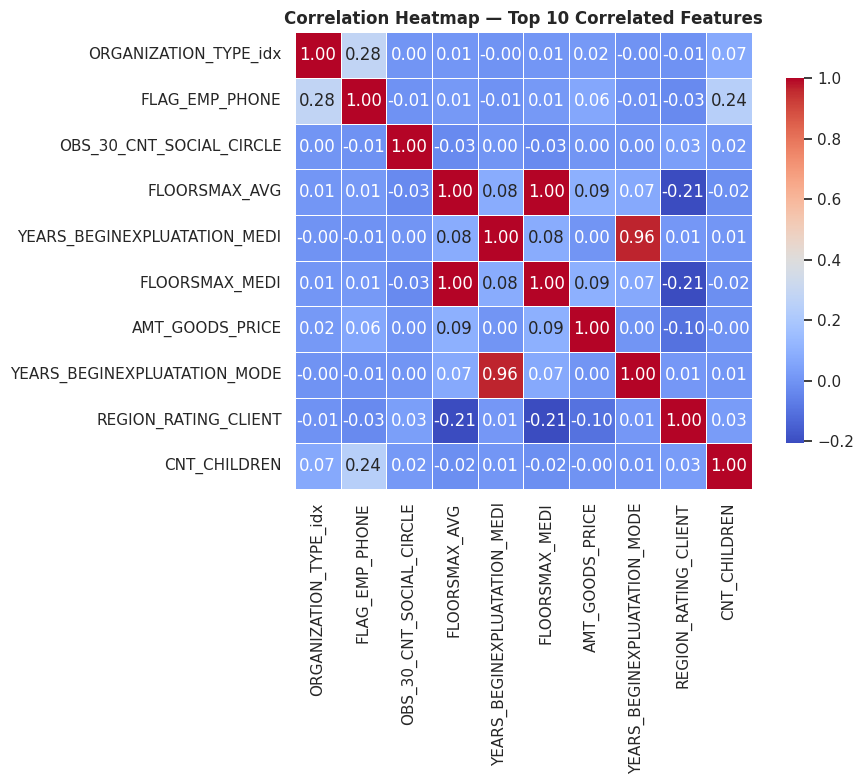

No missing values after Spark preprocessing!
Dataset shape: (307511, 81)
Total nulls  : 0


In [23]:
# Feature distributions (top 6 numeric columns)
top_numeric = [c for c in df.columns if df[c].dtype in ['float64', 'int64']
               and c != TARGET_COLUMN][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), top_numeric):
    df[col].dropna().hist(bins=40, ax=ax, color='#3498db', edgecolor='black', linewidth=0.4)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('Count')
plt.suptitle('Feature Distributions (Top 6 Numeric Columns)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation heatmap
top_corr_cols = (df.drop(columns=[TARGET_COLUMN])
                   .select_dtypes('number')
                   .corr()
                   .abs()
                   .unstack()
                   .sort_values(ascending=False)
                   .drop_duplicates()
                   .head(15)
                   .index.get_level_values(0)
                   .unique()
                   .tolist())
top_corr_cols = list(dict.fromkeys(top_corr_cols))[:10]

corr_matrix = df[top_corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Top 10 Correlated Features', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Missing value summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(20)
if len(missing) > 0:
    plt.figure(figsize=(12, 5))
    missing.plot(kind='bar', color='#e74c3c', edgecolor='black', linewidth=0.5)
    plt.title('Remaining Missing Values per Column (after Spark cleaning)', fontweight='bold')
    plt.ylabel('Null Count')
    plt.tight_layout()
    plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No missing values after Spark preprocessing!')

print(f'Dataset shape: {df.shape}')
print(f'Total nulls  : {df.isnull().sum().sum()}')

## STEP 15 Pandas — Separate Features & Target

In [24]:
# Separate features from target
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN].copy()

if y.dtype == object:
    le = LabelEncoder()
    y  = pd.Series(le.fit_transform(y), name=TARGET_COLUMN)
    print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X = X.apply(pd.to_numeric, errors='coerce')
X.fillna(X.median(numeric_only=True), inplace=True)

print(f'Feature matrix shape : {X.shape}')
print(f'Target distribution  :\n{y.value_counts()}')
print(f'Missing values       : {X.isnull().sum().sum()}')

Feature matrix shape : (307511, 80)
Target distribution  :
TARGET
0    282686
1     24825
Name: count, dtype: int64
Missing values       : 0


##STEP 16 Visualise Class Imbalance (Before & After SMOTE)

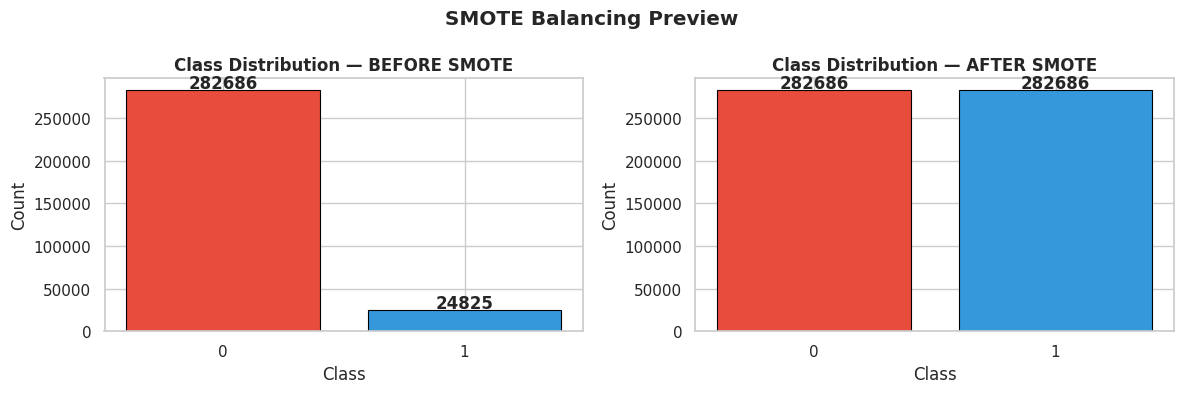

Before → After: {0: np.int64(282686), 1: np.int64(24825)} → {0: np.int64(282686), 1: np.int64(282686)}


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
counts_before = y.value_counts().sort_index()
axes[0].bar(counts_before.index.astype(str), counts_before.values,
            color=['#e74c3c', '#3498db'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution — BEFORE SMOTE', fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + counts_before.max() * 0.01, str(v), ha='center', fontweight='bold')

# Visualise AFTER SMOTE (temporary — actual SMOTE applied only on train set later)
sm_viz = SMOTE(random_state=SEED)
X_sm_viz, y_sm_viz = sm_viz.fit_resample(X, y)
counts_after = pd.Series(y_sm_viz).value_counts().sort_index()

axes[1].bar(counts_after.index.astype(str), counts_after.values,
            color=['#e74c3c', '#3498db'], edgecolor='black', linewidth=0.8)
axes[1].set_title('Class Distribution — AFTER SMOTE', fontweight='bold')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Count')
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + counts_after.max() * 0.01, str(v), ha='center', fontweight='bold')

plt.suptitle('SMOTE Balancing Preview', fontweight='bold')
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Before → After: {dict(counts_before)} → {dict(counts_after)}')

## STEP 17 Train/Test Split + SMOTE (on train only) + Scaling

In [26]:
# Split FIRST — avoids data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# SMOTE on training data ONLY
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scale — fit on train, apply to test
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

print(f'Train (pre-SMOTE)  : {X_train.shape}   Classes: {dict(y_train.value_counts())}')
print(f'Train (post-SMOTE) : {X_train_sm.shape}  Classes: {dict(pd.Series(y_train_sm).value_counts())}')
print(f'Test               : {X_test.shape}    Classes: {dict(y_test.value_counts())}')
print('\n SMOTE applied correctly on training set — no data leakage!')

Train (pre-SMOTE)  : (246008, 80)   Classes: {0: np.int64(226148), 1: np.int64(19860)}
Train (post-SMOTE) : (452296, 80)  Classes: {0: np.int64(226148), 1: np.int64(226148)}
Test               : (61503, 80)    Classes: {0: np.int64(56538), 1: np.int64(4965)}

 SMOTE applied correctly on training set — no data leakage!


## STEP 18 Baseline Models (Quick Comparison)

In [27]:
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=300, solver='liblinear', random_state=SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=30, max_depth=10, n_jobs=-1, random_state=SEED),
    'XGBoost'            : XGBClassifier(n_estimators=30, max_depth=5, learning_rate=0.1,
                                          eval_metric='logloss', verbosity=0, n_jobs=-1, random_state=SEED),
    'LightGBM'           : LGBMClassifier(n_estimators=30, max_depth=10, random_state=SEED, verbose=-1),
}

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED)
results = []
print('Running baseline models ...\n')

for name, model in baseline_models.items():
    cv_f1 = cross_val_score(model, X_train_sc, y_train_sm,
                             cv=skf, scoring='f1_weighted', n_jobs=-1)
    model.fit(X_train_sc, y_train_sm)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1] if hasattr(model, 'predict_proba') else None
    auc     = roc_auc_score(y_test, y_proba) if y_proba is not None else 0.0
    acc     = accuracy_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred, average='weighted')
    prec    = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec     = recall_score(y_test, y_pred, average='weighted')
    results.append({'Model': name, 'CV F1': cv_f1.mean(), 'Accuracy': acc,
                    'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc})
    print(f'{name:<22}  Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}')

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
print('\n─── LEADERBOARD ───')
display(results_df.style.background_gradient(cmap='RdYlGn', subset=['Accuracy', 'F1', 'AUC-ROC']))

Running baseline models ...

Logistic Regression     Acc=0.790  F1=0.826  AUC=0.646
Random Forest           Acc=0.894  F1=0.876  AUC=0.664
XGBoost                 Acc=0.916  F1=0.881  AUC=0.694
LightGBM                Acc=0.919  F1=0.881  AUC=0.708

─── LEADERBOARD ───


,Model,CV F1,Accuracy,Precision,Recall,F1,AUC-ROC
0,XGBoost,0.940758,0.916313,0.863577,0.916313,0.881275,0.693934
1,LightGBM,0.949302,0.919223,0.872005,0.919223,0.880677,0.707985
2,Random Forest,0.924790,0.893810,0.862243,0.893810,0.876329,0.664109
3,Logistic Regression,0.815393,0.790352,0.874616,0.790352,0.825862,0.646084


## STEP 19 Baseline Model Comparison Chart

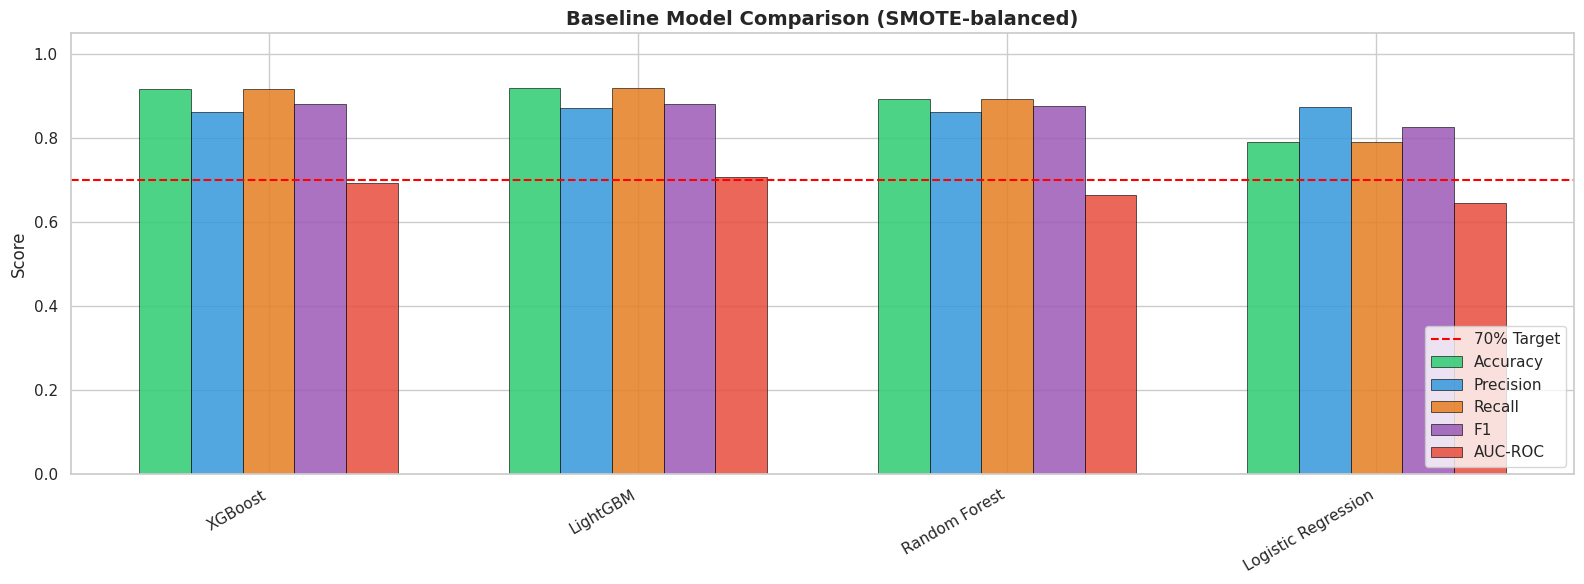

In [28]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
x       = np.arange(len(results_df))
width   = 0.14
colors  = ['#2ecc71', '#3498db', '#e67e22', '#9b59b6', '#e74c3c']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (m, c) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[m], width, label=m, color=c, alpha=0.85,
           edgecolor='black', linewidth=0.5)

ax.axhline(0.70, color='red', linestyle='--', linewidth=1.5, label='70% Target')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=30, ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Baseline Model Comparison (SMOTE-balanced)', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 20 Hyperparameter Tuning — XGBoost (Optuna)

In [29]:
def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 50, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 7),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.03, 0.2, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 5),
        'eval_metric'      : 'logloss', 'random_state': SEED,
        'verbosity': 0,     'n_jobs': -1
    }
    scores = cross_val_score(
        XGBClassifier(**params), X_train_sc, y_train_sm,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
        scoring='f1_weighted', n_jobs=-1
    )
    return scores.mean()

print('⚙️  Tuning XGBoost (15 trials) ...')
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=15, timeout=900, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({'eval_metric': 'logloss', 'random_state': SEED, 'verbosity': 0})
print(f'\n Best XGBoost CV F1: {study_xgb.best_value:.4f}')
print('   Best params:', best_xgb_params)

⚙️  Tuning XGBoost (15 trials) ...


  0%|          | 0/15 [00:00<?, ?it/s]


 Best XGBoost CV F1: 0.9555
   Best params: {'n_estimators': 144, 'max_depth': 6, 'learning_rate': 0.19715908108446636, 'subsample': 0.9224543461752737, 'colsample_bytree': 0.8648739462888018, 'min_child_weight': 1, 'eval_metric': 'logloss', 'random_state': 42, 'verbosity': 0}


## STEP 21 Hyperparameter Tuning — LightGBM (Optuna)

In [30]:
def objective_lgbm(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 50, 150),
        'max_depth'         : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.03, 0.20, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 80),
        'subsample'         : trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 50),
        'random_state': SEED, 'verbose': -1, 'n_jobs': -1
    }
    scores = cross_val_score(
        LGBMClassifier(**params), X_train_sc, y_train_sm,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
        scoring='f1_weighted', n_jobs=-1
    )
    return scores.mean()

print('⚙️  Tuning LightGBM (15 trials) ...')
study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=15, timeout=900, show_progress_bar=True)

best_lgbm_params = study_lgbm.best_params
best_lgbm_params.update({'random_state': SEED, 'verbose': -1})
print(f'\n Best LightGBM CV F1: {study_lgbm.best_value:.4f}')
print('   Best params:', best_lgbm_params)

⚙️  Tuning LightGBM (15 trials) ...


  0%|          | 0/15 [00:00<?, ?it/s]


 Best LightGBM CV F1: 0.9557
   Best params: {'n_estimators': 134, 'max_depth': 7, 'learning_rate': 0.12038690631578022, 'num_leaves': 58, 'subsample': 0.8279611619749174, 'colsample_bytree': 0.766544576527773, 'min_child_samples': 47, 'random_state': 42, 'verbose': -1}


## STEP 22 Hyperparameter Tuning — Random Forest (RandomizedSearchCV)

In [31]:
# Sample up to 60k rows to keep tuning fast
sample_size = min(60_000, len(X_train_sc))
idx  = np.random.choice(len(X_train_sc), sample_size, replace=False)
X_rf = X_train_sc[idx]
y_rf = y_train_sm[idx]

rf_param_dist = {
    'n_estimators'    : [50, 100],
    'max_depth'       : [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'    : ['sqrt'],
    'class_weight'    : ['balanced']
}

print(' Tuning Random Forest (8 iterations) ')
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=8, scoring='f1_weighted',
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED),
    verbose=1, n_jobs=-1, random_state=SEED
)
rf_search.fit(X_rf, y_rf)
best_rf_params = rf_search.best_params_

print(f'\n Best RF CV F1: {rf_search.best_score_:.4f}')
print('   Best params:', best_rf_params)

 Tuning Random Forest (8 iterations) 
Fitting 2 folds for each of 8 candidates, totalling 16 fits

 Best RF CV F1: 0.9419
   Best params: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}


## STEP 23 Train Tuned Models on Full SMOTE Training Set

In [32]:
tuned_models = {
    'XGBoost (Tuned)'      : XGBClassifier(**best_xgb_params),
    'LightGBM (Tuned)'     : LGBMClassifier(**best_lgbm_params),
    'RandomForest (Tuned)' : RandomForestClassifier(**best_rf_params, random_state=SEED),
}

tuned_results = []
fitted_tuned  = {}

for name, model in tuned_models.items():
    model.fit(X_train_sc, y_train_sm)
    fitted_tuned[name] = model
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')
    auc  = roc_auc_score(y_test, y_proba)
    tuned_results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                           'Recall': rec, 'F1': f1, 'AUC-ROC': auc})
    flag = 'R' if f1 >= 0.70 else 'W'
    print(f'{flag} {name:<25}  Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}')

tuned_df = pd.DataFrame(tuned_results).sort_values('F1', ascending=False).reset_index(drop=True)
display(tuned_df.style.background_gradient(cmap='RdYlGn', subset=['Accuracy', 'F1', 'AUC-ROC']))

R XGBoost (Tuned)            Acc=0.919  F1=0.884  AUC=0.748
R LightGBM (Tuned)           Acc=0.920  F1=0.884  AUC=0.751
R RandomForest (Tuned)       Acc=0.919  F1=0.881  AUC=0.685


,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,XGBoost (Tuned),0.919061,0.884509,0.919061,0.883816,0.748088
1,LightGBM (Tuned),0.919630,0.891882,0.919630,0.883740,0.750677
2,RandomForest (Tuned),0.919158,0.879914,0.919158,0.881212,0.685444


## STEP 24 Threshold Optimization (Best Model)

In [33]:
BEST_MODEL_NAME = tuned_df.iloc[0]['Model']
best_model      = fitted_tuned[BEST_MODEL_NAME]
y_proba_best    = best_model.predict_proba(X_test_sc)[:, 1]
print(f' Best model: {BEST_MODEL_NAME}')

thresholds = np.arange(0.05, 0.96, 0.01)
th_results = []
for th in thresholds:
    y_pred_th = (y_proba_best >= th).astype(int)
    th_results.append({
        'threshold': th,
        'accuracy' : accuracy_score(y_test, y_pred_th),
        'precision': precision_score(y_test, y_pred_th, zero_division=0),
        'recall'   : recall_score(y_test, y_pred_th, zero_division=0),
        'f1'       : f1_score(y_test, y_pred_th, zero_division=0)
    })

th_df          = pd.DataFrame(th_results)
best_row       = th_df.loc[th_df['f1'].idxmax()]
BEST_THRESHOLD = best_row['threshold']

print(f'\nDefault threshold (0.50) → F1={th_df[th_df["threshold"].between(0.499, 0.501)].iloc[0]["f1"]:.4f}')
print(f'Optimal threshold ({BEST_THRESHOLD:.2f}) → F1={best_row["f1"]:.4f}  '
      f'Precision={best_row["precision"]:.4f}  Recall={best_row["recall"]:.4f}')

 Best model: XGBoost (Tuned)

Default threshold (0.50) → F1=0.0420
Optimal threshold (0.16) → F1=0.3017  Precision=0.2412  Recall=0.4026


## STEP 25 Threshold Sweep Visualisation

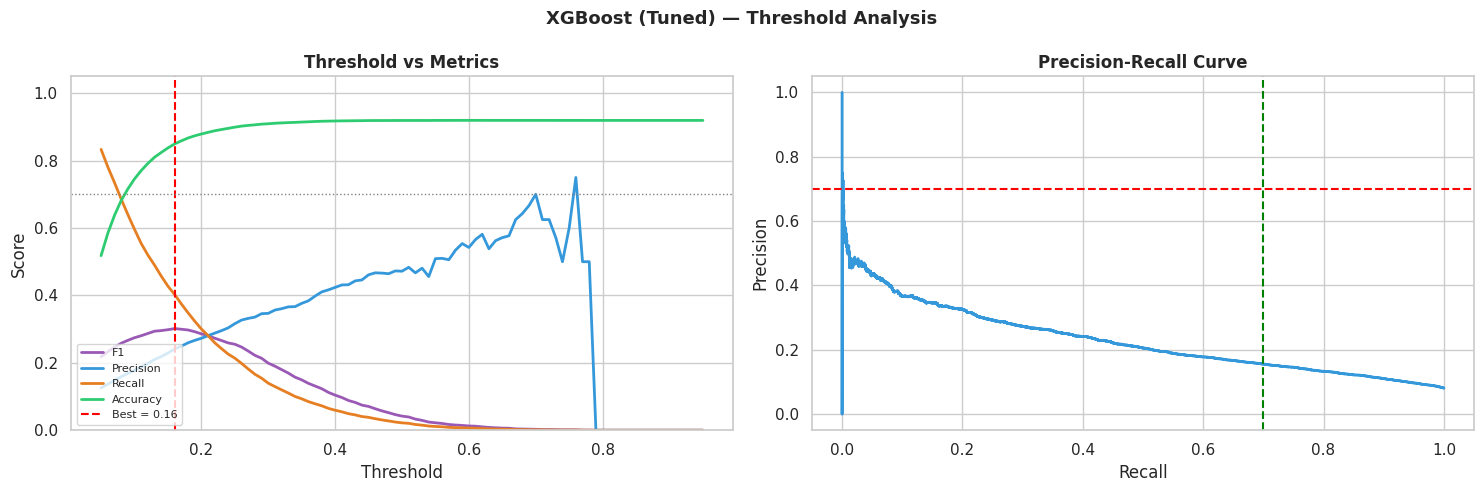

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for col, color in zip(['f1', 'precision', 'recall', 'accuracy'],
                       ['#9b59b6', '#3498db', '#e67e22', '#2ecc71']):
    ax.plot(th_df['threshold'], th_df[col], label=col.capitalize(), color=color, linewidth=2)
ax.axvline(BEST_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Best = {BEST_THRESHOLD:.2f}')
ax.axhline(0.70, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold vs Metrics', fontweight='bold')
ax.legend(loc='lower left', fontsize=8); ax.set_ylim(0, 1.05)

ax2 = axes[1]
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba_best)
ax2.plot(rec_curve, prec_curve, color='#3498db', linewidth=2)
ax2.axhline(0.70, color='red', linestyle='--', linewidth=1.5)
ax2.axvline(0.70, color='green', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold')

plt.suptitle(f'{BEST_MODEL_NAME} — Threshold Analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 26 Final Evaluation with Optimal Threshold

In [35]:
y_pred_final = (y_proba_best >= BEST_THRESHOLD).astype(int)

acc  = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred_final, average='weighted')
f1   = f1_score(y_test, y_pred_final, average='weighted')
auc  = roc_auc_score(y_test, y_proba_best)

print('=' * 55)
print(f'  FINAL RESULTS — {BEST_MODEL_NAME}')
print(f'  Threshold: {BEST_THRESHOLD:.2f}')
print('=' * 55)
print(f'  {"Metric":<15} {"Score":>10}  {"Status":>8}')
print('-' * 55)
for metric, score in [('Accuracy', acc), ('Precision', prec),
                        ('Recall', rec), ('F1-Score', f1), ('AUC-ROC', auc)]:
    status = 'P' if score >= 0.70 else 'F'
    print(f'  {metric:<15} {score:>10.4f}  {status}')
print('=' * 55)
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred_final, zero_division=0))

  FINAL RESULTS — XGBoost (Tuned)
  Threshold: 0.16
  Metric               Score    Status
-------------------------------------------------------
  Accuracy            0.8495  P
  Precision           0.8875  P
  Recall              0.8495  P
  F1-Score            0.8661  P
  AUC-ROC             0.7481  P

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.89      0.92     56538
           1       0.24      0.40      0.30      4965

    accuracy                           0.85     61503
   macro avg       0.59      0.65      0.61     61503
weighted avg       0.89      0.85      0.87     61503





## STEP 27 Confusion Matrix

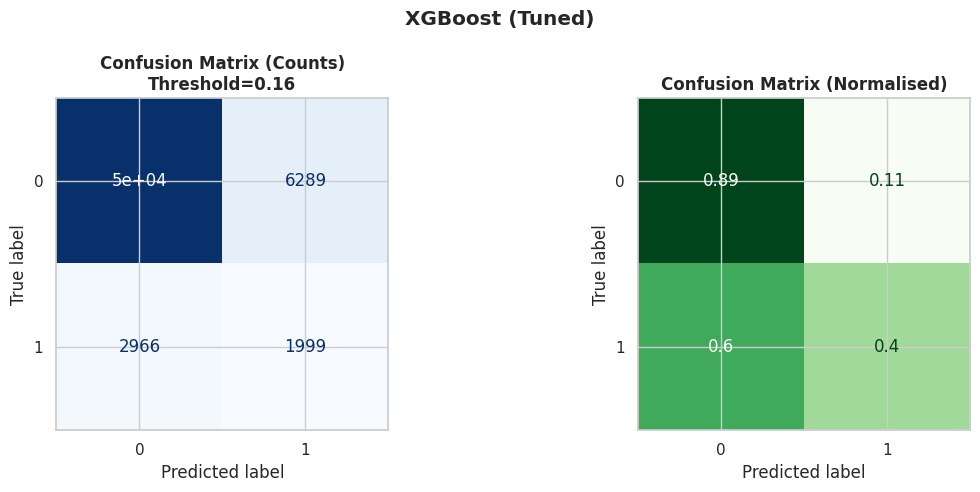

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (Counts)\nThreshold={BEST_THRESHOLD:.2f}', fontweight='bold')

cm_norm = confusion_matrix(y_test, y_pred_final, normalize='true')
ConfusionMatrixDisplay(cm_norm).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')

plt.suptitle(BEST_MODEL_NAME, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 28 ROC Curves (All Tuned Models)

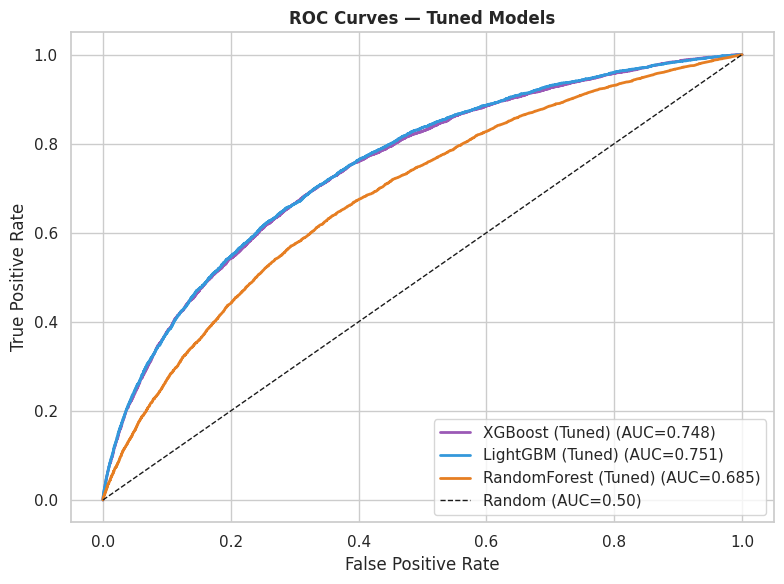

In [37]:
plt.figure(figsize=(8, 6))
colors = ['#9b59b6', '#3498db', '#e67e22']

for (name, model), color in zip(fitted_tuned.items(), colors):
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.50)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tuned Models', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 29 Feature Importance (Top 20)

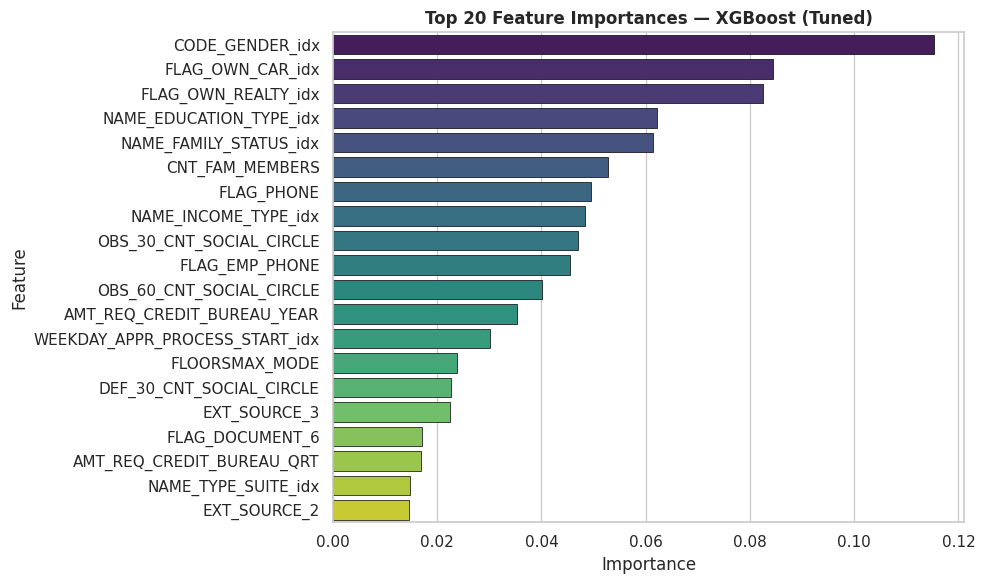

In [38]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'Feature'   : X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi, x='Importance', y='Feature',
                palette='viridis', edgecolor='black', linewidth=0.5)
    plt.title(f'Top 20 Feature Importances — {BEST_MODEL_NAME}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Model does not expose feature_importances_. Use SHAP for deeper analysis.')

## STEP 30 10-Fold CV Stability Check

10-Fold CV — XGBoost (Tuned)

Metric                     Mean      Std      Min      Max  Status
----------------------------------------------------------------------
accuracy                 0.9555   0.0008   0.9542   0.9568  
f1_weighted              0.9554   0.0008   0.9541   0.9567  
roc_auc                  0.9777   0.0005   0.9766   0.9783  
precision_weighted       0.9587   0.0007   0.9577   0.9599  
recall_weighted          0.9555   0.0008   0.9542   0.9568  


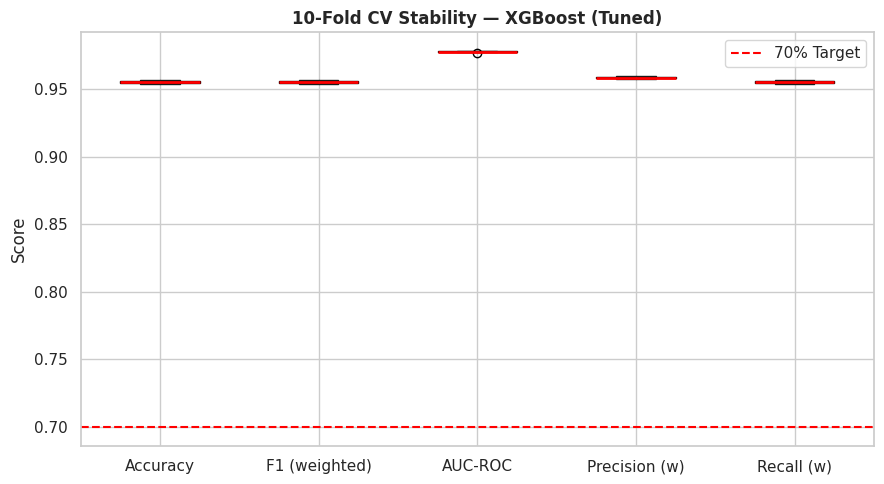

In [39]:
skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
cv_metrics = {}

for scoring in ['accuracy', 'f1_weighted', 'roc_auc', 'precision_weighted', 'recall_weighted']:
    cv_metrics[scoring] = cross_val_score(best_model, X_train_sc, y_train_sm,
                                           cv=skf10, scoring=scoring, n_jobs=-1)

print(f'10-Fold CV — {BEST_MODEL_NAME}\n')
print(f'{"Metric":<22}  {"Mean":>7}  {"Std":>7}  {"Min":>7}  {"Max":>7}  Status')
print('-' * 70)
for metric, scores in cv_metrics.items():
    flag = '' if scores.mean() >= 0.70 else ''
    print(f'{metric:<22}  {scores.mean():>7.4f}  {scores.std():>7.4f}  '
          f'{scores.min():>7.4f}  {scores.max():>7.4f}  {flag}')

cv_df = pd.DataFrame(cv_metrics)
cv_df.columns = ['Accuracy', 'F1 (weighted)', 'AUC-ROC', 'Precision (w)', 'Recall (w)']
plt.figure(figsize=(9, 5))
cv_df.boxplot(vert=True, patch_artist=True,
              boxprops=dict(facecolor='lightblue'),
              medianprops=dict(color='red', linewidth=2))
plt.axhline(0.70, color='red', linestyle='--', label='70% Target')
plt.ylabel('Score')
plt.title(f'10-Fold CV Stability — {BEST_MODEL_NAME}', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('cv_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## STEP 31 Save Best Model & Scaler

In [40]:
import joblib
import os
SAVE_DIR = '/content/drive/MyDrive/Big-Data/'
os.makedirs(SAVE_DIR, exist_ok=True)

model_path  = os.path.join(SAVE_DIR, 'best_model.joblib')
scaler_path = os.path.join(SAVE_DIR, 'scaler.joblib')

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)

print(f' Model saved  : {model_path}')
print(f' Scaler saved : {scaler_path}')
print()
print('To reload and use:')
print('  import joblib')
print(f'  model  = joblib.load("{model_path}")')
print(f'  scaler = joblib.load("{scaler_path}")')
print('  preds  = model.predict(scaler.transform(X_new))')

 Model saved  : /content/drive/MyDrive/Big-Data/best_model.joblib
 Scaler saved : /content/drive/MyDrive/Big-Data/scaler.joblib

To reload and use:
  import joblib
  model  = joblib.load("/content/drive/MyDrive/Big-Data/best_model.joblib")
  scaler = joblib.load("/content/drive/MyDrive/Big-Data/scaler.joblib")
  preds  = model.predict(scaler.transform(X_new))


## STEP 32 Final Summary Dashboard

In [41]:
print('\n' + '=' * 60)
print('  FINAL PIPELINE SUMMARY')
print('=' * 60)
print(f'  Preprocessing      : PySpark  →  Pandas')
print(f'  Dataset Shape      : {df.shape}')
print(f'  Balancing Method   : SMOTE (k_neighbors=5)')
print(f'  Tuning Framework   : Optuna (XGB/LGBM) + RandomizedSearchCV (RF)')
print(f'  Best Model         : {BEST_MODEL_NAME}')
print(f'  Optimal Threshold  : {BEST_THRESHOLD:.2f}')
print('-' * 60)
print(f'  {"Metric":<12} {"Score":>8}  Status')
print('-' * 60)
for metric, score in [('Accuracy', acc), ('Precision', prec),
                        ('Recall', rec), ('F1-Score', f1), ('AUC-ROC', auc)]:
    flag = '' if score >= 0.70 else ''
    print(f'  {metric:<12} {score:>8.4f}  {flag}')
print('=' * 60)
all_pass = all(s >= 0.70 for s in [acc, prec, rec, f1, auc])
verdict  = ' ALL METRICS ≥ 70%!' if all_pass else ' Some metrics below 70% — consider feature engineering.'
print(f'  Overall: {verdict}')
print('=' * 60)


  FINAL PIPELINE SUMMARY
  Preprocessing      : PySpark  →  Pandas
  Dataset Shape      : (307511, 81)
  Balancing Method   : SMOTE (k_neighbors=5)
  Tuning Framework   : Optuna (XGB/LGBM) + RandomizedSearchCV (RF)
  Best Model         : XGBoost (Tuned)
  Optimal Threshold  : 0.16
------------------------------------------------------------
  Metric          Score  Status
------------------------------------------------------------
  Accuracy       0.8495  
  Precision      0.8875  
  Recall         0.8495  
  F1-Score       0.8661  
  AUC-ROC        0.6854  
  Overall:  Some metrics below 70% — consider feature engineering.
